## Verification of Two Model Forecasts vs Observations (Measurements)

Documentation about DMI dat and Scores can be found here:
- https://opendatadocs.dmi.govcloud.dk/APIs/Meteorological_Observation_API
- https://scores.readthedocs.io/en/stable/index.html

Plese define the folling variables to define the data you want to verify. Each model var must have a corresponding obs var after processing.

In [56]:
import os
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr

from dask.diagnostics import ProgressBar

from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree, KDTree
from scipy.stats import gaussian_kde, kurtosis, skew, wasserstein_distance

from scores.categorical import ThresholdEventOperator as TEO
from scores.continuous import mae, mean_error, mse, rmse
from scores.continuous.correlation import pearsonr

In [ ]:
# Constants for station obs
path_obs = "danra_ex_fc/danra_station_observations.zarr"
url_obs = "https://dmigw.govcloud.dk/v2/metObs/collections/observation/items"
api_key = "8dff599e-9a48-46eb-a166-72f2f722645e"

In [53]:
### DEFAULTS ###
# This config will be applied to the data before any plotting. The data will be
# sliced and indexed according to the values in this config.The whole analysis and
# plotting will be done on the reduced data.

# IF YOUR DATA HAS DIFFERENT DIMENSIONS OR NAMES, PLEASE ADJUST THE CELLS BELOW
# MAKE SURE THE XARRAY DATASETS LOOK OKAY BEFORE RUNNING CHAPTER 1-4

# This path should point to the NWP forecast data in zarr format
PATH_NWP = "danra_ex_fc/danra_nwp_ex_forecasts.zarr"
# This path should point to the ML forecast data in zarr format (e.g. produced by neural-lam in `eval` mode)
PATH_ML = "danra_ex_fc/danra_ml_ex_forecasts.zarr"
# This path should point to the observations data in zarr format
PATH_OBS = path_obs

# All variables should map to the same values.
# For obs please also theck the pre-processing in the cell below
# Often some data wrangling is required to match the variables
# OBS and ML variables should match and always be present
VARIABLES_ML = {
    "t2m": "temperature_2m",
    "u10m": "wind_u_10m",
    "v10m": "wind_v_10m",
    "pres_seasurface": "seasurface_pressure",
}
# The function calls are flexible to allow for missing nwp data
VARIABLES_NWP = {
    "t2m": "temperature_2m",
    "u10m": "wind_u_10m",
    "v10m": "wind_v_10m",
    "pres_seasurface": "seasurface_pressure",
}
VARIABLES_OBS = [
    "wind_speed_past1h",
    "wind_dir_past1h",
    "temp_dry",
    "pressure_at_sea",
    #"pressure",
]
# Similar mapping to ML/NWP
OBS_VAR_MAPPING = {
    "t2m": "temperature_2m",
    "u10m": "wind_u_10m",
    "v10m": "wind_v_10m",
    "pres_seasurface": "seasurface_pressure",
}

# Add units dictionary after the imports
# units from zarr archives are not reliable and should rather be defined here
VARIABLE_UNITS = {
    # Surface and near-surface variables
    "temperature_2m": "K",
    "wind_u_10m": "m/s",
    "wind_v_10m": "m/s",
    "seasurface_pressure": "Pa",
}

# elapsed forecast duration in steps for the forecast - [0] refers to the first forecast step at t+1
# this should be a list of integers
# ELAPSED_FORECAST_DURATION = list(range(0, 120, 1))
# TODO Update
ELAPSED_FORECAST_DURATION = [0, 1, 2, 5]

# Select specific start_times for the forecast. This is the start and end of
# a slice in xarray. The start_time is included, the end_time is excluded.
# This should be a list of two strings in the format "YYYY-MM-DDTHH:MM:SS"
# Should be handy to evaluate certain dates, e.g. for a case study of a storm
# TODO Update
#START_TIMES = ["2019-10-31T00:00:00", "2020-10-23T13:00:00"]  # Full year
START_TIMES = ["2020-01-02T00:00", "2020-01-04T00:00"]  

# Select specific plot times for the forecast (will be used to create maps for all variables)
# This only affect chapter one with the plotting of the maps
# Map creation takes a lot of time so this is limited to a single time step
# Simply rerun these cells and chapter one for more time steps
# TODO Update
PLOT_TIME = "2020-01-03T00:00:00"

# Define Thresholds for the ETS metric (Equitable Threat Score)
# These are calculated for wind and precipitation if available
# The score creates contingency tables for different thresholds
# The ETS is calculated for each threshold and the results are plotted
# The default thresholds are [0.1, 1, 5] for precipitation and [2.5, 5, 10] for wind
THRESHOLDS_PRECIPITATION = [0.1, 1, 5]  # mm/h
THRESHOLDS_WIND = [2.5, 5, 10]  # m/s

# Define the metrics to compute for the verification
# Some additional verifications will always be computed if the repsective vars
# are available in the data
METRICS = [
    "MAE",
    "RMSE",
    "MSE",
    "ME",
    "STDEV_ERR",
    "RelativeMAE",
    "RelativeRMSE",
    "PearsonR",
    "Wasserstein",
]

# Map projection settings for plotting of the ml data
PROJECTION = ccrs.LambertConformal(
    central_longitude=25.0,
    central_latitude=56.7,
    standard_parallels=[56.7, 56.7],
    globe=ccrs.Globe(
        semimajor_axis=6367470.0,
        semiminor_axis=6367470.0,
    ),
)

# For some chapters a random seed is required to reproduce the results
RANDOM_SEED = 42

# The DPI used in all plots in the notebook, export to pdf will always be 300 DPI
DPI = 100

# Takes a long time, but if you see NaN in your output, you can set this to True
# This will check if there are any missing values in the data further below
CHECK_MISSING = True
# In this script missing data is allowed as observations often have missing values
# All time steps with missing values will be omitted from the verification
# - Scores/Xarray masked arrays are created and false values are omitted by default
# - For Scipy metrics, we need to convert to numpy arrays and change nan-policy to 'omit'.
# - Fore the wasserstein metric and the wind vector without internal nan-handling policy,
#  we need to remove the missing values for obs, ml, nwp before calculating the metric

# Font sizes for consistent plotting (different fig-sizes wil require different font sizes)
FONT_SIZES = {
    "axes": 13,  # Axis labels and titles
    "ticks": 13,  # Tick labels
    "legend": 13,  # Legend text
    "cbar": 13,  # Colorbar labels
    "suptitle": 15,  # Figure suptitle
    "title": 13,  # Axes titles
    "stats": 13,  # Statistics text in plots
}

### Read in datasets

In [13]:
ds_nwp = xr.open_zarr(PATH_NWP)
ds_nwp = ds_nwp.sel(analysis_time=slice(*START_TIMES))
ds_nwp = ds_nwp[VARIABLES_NWP.keys()].rename(VARIABLES_NWP)
ds_nwp = ds_nwp.rename_dims({
    "analysis_time": "start_time",
})
ds_nwp = ds_nwp.rename_vars({
    "analysis_time": "start_time",
    "lon": "longitude",
    "lat": "latitude",
})
forecast_times = (
    ds_nwp.start_time.values[:, None] + ds_nwp.elapsed_forecast_duration.values
)
ds_nwp = ds_nwp.assign_coords(
    forecast_time=(
        ("start_time", "elapsed_forecast_duration"),
        forecast_times,
    )
)

# The NWP data starts at elapsed forecast duration 3h
ds_nwp = ds_nwp.isel(
    elapsed_forecast_duration=ELAPSED_FORECAST_DURATION
)

ds_nwp = ds_nwp.transpose("start_time", "elapsed_forecast_duration", "x", "y")
ds_nwp = ds_nwp[
    [
        "start_time",
        "elapsed_forecast_duration",
        "x",
        "y",
        *VARIABLES_NWP.values(),
    ]
]

ds_nwp

<xarray.Dataset> Size: 305MB
Dimensions:                    (start_time: 5, elapsed_forecast_duration: 4,
                                x: 789, y: 589)
Coordinates:
  * start_time                 (start_time) datetime64[ns] 40B 2020-01-02 ......
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 32B ...
  * x                          (x) float64 6kB -1.999e+06 ... -2.925e+04
  * y                          (y) float64 5kB -6.095e+05 ... 8.605e+05
    latitude                   (x, y) float64 4MB dask.array<chunksize=(263, 295), meta=np.ndarray>
    longitude                  (x, y) float64 4MB dask.array<chunksize=(263, 295), meta=np.ndarray>
    time                       (start_time, elapsed_forecast_duration) datetime64[ns] 160B dask.array<chunksize=(5, 4), meta=np.ndarray>
    forecast_time              (start_time, elapsed_forecast_duration) datetime64[ns] 160B ...
Data variables:
    temperature_2m             (start_time, elapsed_forecast_duration, x, y) float64 74MB dask.array<chunksize=(2, 4, 263, 295), meta=np.ndarray>
    wind_u_10m                 (start_time, elapsed_forecast_duration, x, y) float64 74MB dask.array<chunksize=(2, 4, 263, 295), meta=np.ndarray>
    wind_v_10m                 (start_time, elapsed_forecast_duration, x, y) float64 74MB dask.array<chunksize=(2, 4, 263, 295), meta=np.ndarray>
    seasurface_pressure        (start_time, elapsed_forecast_duration, x, y) float64 74MB dask.array<chunksize=(2, 4, 263, 295), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    contact:      Leif Denby <lcd@dmi.dk>, Danish Meteorological Institute
    description:  Near-surface prognostic variables forecast for 2019-01-01T0...
    license:      CC-BY-4.0: https://creativecommons.org/licenses/by/4.0/

In [14]:
ds_ml = xr.open_zarr(PATH_ML)
ds_ml = ds_ml.sel(state_feature=list(VARIABLES_ML.keys()))
ds_ml = ds_ml.sel(start_time=slice(*START_TIMES))
for feature in ds_ml.state_feature.values:
    ds_ml[VARIABLES_ML[feature]] = ds_ml["state"].sel(state_feature=feature)
forecast_times = (
    ds_ml.start_time.values[:, None] + ds_ml.elapsed_forecast_duration.values
)
ds_ml = ds_ml.assign_coords(
    forecast_time=(
        ("start_time", "elapsed_forecast_duration"),
        forecast_times,
    )
)
ds_ml = ds_ml.drop_vars(["state", "state_feature", "time"])
ds_ml = ds_ml.transpose("start_time", "elapsed_forecast_duration", "x", "y")
ds_ml = ds_ml[
    [
        "start_time",
        "elapsed_forecast_duration",
        "x",
        "y",
        *VARIABLES_ML.values(),
    ]
]
ds_ml = ds_ml.assign_coords({
    "latitude": ds_nwp.latitude,
    "longitude": ds_nwp.longitude,
})

ds_ml = ds_ml.isel(elapsed_forecast_duration=ELAPSED_FORECAST_DURATION)

ds_ml

<xarray.Dataset> Size: 156MB
Dimensions:                    (start_time: 5, elapsed_forecast_duration: 4,
                                x: 789, y: 589)
Coordinates:
  * start_time                 (start_time) datetime64[ns] 40B 2020-01-02 ......
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 32B ...
  * x                          (x) float64 6kB -1.999e+06 ... -2.925e+04
  * y                          (y) float64 5kB -6.095e+05 ... 8.605e+05
    forecast_time              (start_time, elapsed_forecast_duration) datetime64[ns] 160B ...
    latitude                   (x, y) float64 4MB dask.array<chunksize=(263, 295), meta=np.ndarray>
    longitude                  (x, y) float64 4MB dask.array<chunksize=(263, 295), meta=np.ndarray>
Data variables:
    temperature_2m             (start_time, elapsed_forecast_duration, x, y) float32 37MB dask.array<chunksize=(1, 1, 789, 589), meta=np.ndarray>
    wind_u_10m                 (start_time, elapsed_forecast_duration, x, y) float32 37MB dask.array<chunksize=(1, 1, 789, 589), meta=np.ndarray>
    wind_v_10m                 (start_time, elapsed_forecast_duration, x, y) float32 37MB dask.array<chunksize=(1, 1, 789, 589), meta=np.ndarray>
    seasurface_pressure        (start_time, elapsed_forecast_duration, x, y) float32 37MB dask.array<chunksize=(1, 1, 789, 589), meta=np.ndarray>

### Retrieve observations

In [17]:
# From first forecasted time in first forecast, to last forecasted time in last forecast
datetime_start = np.datetime_as_string(ds_ml.forecast_time.values[0,0], unit="s")
datetime_end = np.datetime_as_string(ds_ml.forecast_time.values[-1,-1], unit="s")
datetime_range = f"{datetime_start}Z/{datetime_end}Z"
print(datetime_range)

2020-01-02T03:00:00Z/2020-01-04T18:00:00Z


In [18]:
dfs = {}

for var in VARIABLES_OBS:
    params = {
        "api-key": api_key,
        "datetime": datetime_range,
        "parameterId": var,
        "bbox": "7,54,16,58",  # Bounding box for Denmark
        "limit": 100000,
    }

    # Fetch the data
    response = requests.get(url_obs, params=params)
    data = response.json()
    gdf = gpd.GeoDataFrame.from_features(data["features"])
    gdf["time"] = pd.to_datetime(gdf["observed"], utc=True)
    df_pivot = gdf.pivot(index="time", columns="stationId", values="value")
    dfs[var] = df_pivot

In [26]:
# Get the set of stations for each variable
station_sets = [set(dfs[var].columns) for var in VARIABLES_OBS]

# Find common stations across all variables using set intersection
common_stations = set.intersection(*station_sets)

# Convert to sorted list if needed
common_stations = sorted(list(common_stations))

# Print the number of common stations and their IDs
print(f"Number of stations with data for all variables: {len(common_stations)}")
print("\nStation IDs:")
print(common_stations)

# Filter your DataFrames to keep only common stations
dfs_filtered = {}
for var in VARIABLES_OBS:
    dfs_filtered[var] = dfs[var][common_stations]
# filter gdf by stations as well
gdf_filtered = gdf[gdf["stationId"].isin(common_stations)]

Number of stations with data for all variables: 50

Station IDs:
['06030', '06032', '06041', '06049', '06052', '06056', '06058', '06060', '06065', '06068', '06070', '06072', '06073', '06074', '06079', '06080', '06081', '06093', '06096', '06102', '06104', '06108', '06110', '06116', '06118', '06119', '06120', '06123', '06124', '06126', '06135', '06138', '06141', '06147', '06149', '06151', '06154', '06156', '06159', '06168', '06169', '06170', '06174', '06180', '06181', '06183', '06188', '06190', '06193', '06197']


In [27]:
# Convert model times to UTC datetime (assuming ds_model is available)
#model_times = pd.to_datetime(ds_model["time"].values).tz_localize("UTC")
model_times = np.unique(ds_ml.forecast_time.values.flatten())
model_times_utc = pd.to_datetime(model_times).tz_localize("UTC")
print(model_times_utc)
# Filter each DataFrame in the dictionary
# Assuming the DataFrames in dfs_filtered already have datetime index
dfs_filtered = {
    k: v[v.index.isin(model_times_utc)] for k, v in dfs_filtered.items()
}
# Filter gdf_filtered
gdf_filtered = gdf_filtered.set_index("time")
gdf_filtered = gdf_filtered[gdf_filtered.index.isin(model_times_utc)]

DatetimeIndex(['2020-01-02 03:00:00+00:00', '2020-01-02 06:00:00+00:00',
               '2020-01-02 09:00:00+00:00', '2020-01-02 15:00:00+00:00',
               '2020-01-02 18:00:00+00:00', '2020-01-02 21:00:00+00:00',
               '2020-01-03 03:00:00+00:00', '2020-01-03 06:00:00+00:00',
               '2020-01-03 09:00:00+00:00', '2020-01-03 15:00:00+00:00',
               '2020-01-03 18:00:00+00:00', '2020-01-03 21:00:00+00:00',
               '2020-01-04 03:00:00+00:00', '2020-01-04 06:00:00+00:00',
               '2020-01-04 09:00:00+00:00', '2020-01-04 18:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


In [28]:
# Combine the DataFrames into a single xarray Dataset
ds_obs = xr.Dataset(
    {
        var: (["time", "stationId"], dfs_filtered[var].values)
        for var in VARIABLES_OBS
    },
    coords={
        "time": model_times,
        "stationId": dfs_filtered[VARIABLES_OBS[0]].columns,
        "lat": (
            "stationId",
            gdf_filtered.groupby("stationId")["geometry"].first().y,
        ),
        "lon": (
            "stationId",
            gdf_filtered.groupby("stationId")["geometry"].first().x,
        ),
    },
)

#ds_obs = ds_obs.sel(time=ds_model.time)
ds_obs = ds_obs.sortby("time")
ds_obs

<xarray.Dataset> Size: 27kB
Dimensions:            (time: 16, stationId: 50)
Coordinates:
  * time               (time) datetime64[ns] 128B 2020-01-02T03:00:00 ... 202...
  * stationId          (stationId) object 400B '06030' '06032' ... '06197'
    lat                (stationId) float64 400B 57.1 57.38 57.74 ... 55.3 55.06
    lon                (stationId) float64 400B 9.851 10.33 10.63 ... 14.77 15.1
Data variables:
    wind_speed_past1h  (time, stationId) float64 6kB 7.7 9.2 9.2 ... 11.9 5.9
    wind_dir_past1h    (time, stationId) float64 6kB 237.0 240.0 ... 320.0 311.0
    temp_dry           (time, stationId) float64 6kB 5.5 5.0 5.8 ... 4.3 5.1 3.5
    pressure_at_sea    (time, stationId) float64 6kB 1.02e+03 ... 1.014e+03

Conversion of wind speed and direction to u and v.

In [31]:
class SynopProcessor:
    def __init__(self):
        self.var_mapping = {
            "temp_dry": "t2m",
            "pressure_at_sea": "pres_seasurface",
            #"pressure": "pres0m",
        }

    def calculate_wind_components(
        self, ds, speed_var="wind_speed_past1h", dir_var="wind_dir_past1h"
    ):
        """Calculate u and v wind components from speed and direction."""
        ds = ds.copy()
        ds["u10m"] = ds[speed_var] * np.cos(np.radians(90 - ds[dir_var]))
        ds["v10m"] = ds[speed_var] * np.sin(np.radians(90 - ds[dir_var]))
        ds = ds.drop_vars([speed_var, dir_var])
        return ds

    def rename_variables(self, ds):
        """Rename variables according to mapping."""
        return ds.rename_vars(self.var_mapping)

    def convert_units(self, ds):
        """Convert temperature to Kelvin and pressure to Pa."""
        ds = ds.copy()
        # Convert temperature from Celsius to Kelvin
        if "temp_dry" in ds:
            ds["temp_dry"] = ds["temp_dry"] + 273.15

        # Convert pressure from hPa to Pa
        for pressure_var in ["pressure", "pressure_at_sea"]:
            if pressure_var in ds:
                ds[pressure_var] = ds[pressure_var] * 100
        return ds

    def process_dataset(self, ds):
        """Process the entire dataset with unit conversions, wind calculation and variable renaming."""
        ds = self.convert_units(ds)
        ds = self.calculate_wind_components(ds)
        ds = self.rename_variables(ds)
        return ds

In [32]:
processor = SynopProcessor()
ds_obs = processor.process_dataset(ds_obs)

Plotting of selected variable (?)

In [ ]:
date = ds_obs.isel(time=0)["time"].values
formatted_datetime = pd.to_datetime(date)
formatted_date = formatted_datetime.strftime("%Y-%m-%d")
hour = formatted_datetime.strftime("%H")

<xarray.Dataset> Size: 3kB
Dimensions:          (stationId: 50)
Coordinates:
    time             datetime64[ns] 8B 2020-01-02T03:00:00
  * stationId        (stationId) object 400B '06030' '06032' ... '06193' '06197'
    lat              (stationId) float64 400B 57.1 57.38 57.74 ... 55.3 55.06
    lon              (stationId) float64 400B 9.851 10.33 10.63 ... 14.77 15.1
Data variables:
    t2m              (stationId) float64 400B 278.6 278.1 278.9 ... 277.0 276.6
    pres_seasurface  (stationId) float64 400B 1.02e+05 1.019e+05 ... 1.024e+05
    u10m             (stationId) float64 400B -6.458 -7.967 ... -13.2 -7.631
    v10m             (stationId) float64 400B -4.194 -4.6 ... -4.035 -2.045

In [37]:
ds_obs

<xarray.Dataset> Size: 27kB
Dimensions:          (time: 16, stationId: 50)
Coordinates:
  * time             (time) datetime64[ns] 128B 2020-01-02T03:00:00 ... 2020-...
  * stationId        (stationId) object 400B '06030' '06032' ... '06193' '06197'
    lat              (stationId) float64 400B 57.1 57.38 57.74 ... 55.3 55.06
    lon              (stationId) float64 400B 9.851 10.33 10.63 ... 14.77 15.1
Data variables:
    t2m              (time, stationId) float64 6kB 278.6 278.1 ... 278.2 276.6
    pres_seasurface  (time, stationId) float64 6kB 1.02e+05 ... 1.014e+05
    u10m             (time, stationId) float64 6kB -6.458 -7.967 ... -4.453
    v10m             (time, stationId) float64 6kB -4.194 -4.6 ... 9.116 3.871

Text(0, 0.5, 'Latitude')

/home/joel/miniconda3/envs/mllam/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/joel/miniconda3/envs/mllam/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


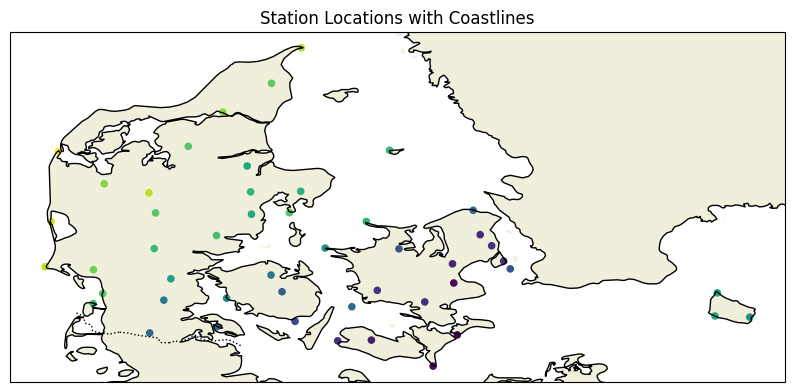

In [50]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)

# Scatter plot of station locations
ax.scatter(ds_obs.lon, ds_obs.lat, transform=ccrs.PlateCarree(), s=20, c=ds_obs.t2m.isel(time=0), marker='o')

# Set plot title and labels
plt.title('Station Locations with Coastlines')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [51]:
# Save obs as zarr
ds_obs.to_zarr(PATH_OBS, mode="w")

### Read in obs data

In [54]:
ds_obs = xr.open_zarr(PATH_OBS)
ds_obs = ds_obs.rename_vars(OBS_VAR_MAPPING)
# Don't need any of the below
#ds_obs = ds_obs.sel(time=np.unique(ds_ml.forecast_time.values.flatten()))
#ds_obs = ds_obs.where(ds_obs != 32767, np.nan)
#ds_obs = calculate_wind_components(ds_obs)
#ds_obs["temperature_2m"] += 273.15  # Convert to Kelvin
#ds_obs["surface_pressure"] *= 100  # Convert to Pa
ds_obs

<xarray.Dataset> Size: 27kB
Dimensions:              (stationId: 50, time: 16)
Coordinates:
    lat                  (stationId) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    lon                  (stationId) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * stationId            (stationId) object 400B '06030' '06032' ... '06197'
  * time                 (time) datetime64[ns] 128B 2020-01-02T03:00:00 ... 2...
Data variables:
    seasurface_pressure  (time, stationId) float64 6kB dask.array<chunksize=(16, 50), meta=np.ndarray>
    temperature_2m       (time, stationId) float64 6kB dask.array<chunksize=(16, 50), meta=np.ndarray>
    wind_u_10m           (time, stationId) float64 6kB dask.array<chunksize=(16, 50), meta=np.ndarray>
    wind_v_10m           (time, stationId) float64 6kB dask.array<chunksize=(16, 50), meta=np.ndarray>

### Define plotting functions

In [57]:
# Create directories for plots and tables
Path("plots").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)

# Colorblind-friendly color palette
COLORS = {
    "gt": "#000000",  # Black
    "ml": "#E69F00",  # Orange
    "nwp": "#56B4E9",  # Light blue
    "error": "#CC79A7",  # Pink
}

# Line styles and markers for accessibility
LINE_STYLES = {
    "gt": ("solid", "o"),
    "ml": ("dashed", "s"),
    "nwp": ("dotted", "^"),
}

# Set global font sizes
plt.rcParams.update({
    "font.size": FONT_SIZES["axes"],
    "axes.titlesize": FONT_SIZES["axes"],
    "axes.labelsize": FONT_SIZES["axes"],
    "xtick.labelsize": FONT_SIZES["ticks"],
    "ytick.labelsize": FONT_SIZES["ticks"],
    "legend.fontsize": FONT_SIZES["legend"],
    "figure.titlesize": FONT_SIZES["suptitle"],
})

# Colorblind-friendly colormap for 2D plots
COLORMAP = "viridis"


def save_plot(fig, name, time=None, remove_title=True, dpi=300):
    """Helper function to save plots consistently

    Args:
        fig: matplotlib figure object
        name (str): base name for the plot file
        time (datetime, optional): timestamp to append to filename
        remove_title (bool): remove suptitle/title hierarchically if True
        dpi (int): resolution for the saved figure, defaults to 300
    """
    if time is not None:
        name = f"{name}_{time.dt.strftime('%Y%m%d_%H').values}"

    # Sanitize filename by replacing problematic characters
    safe_name = name.replace("/", "_per_")

    # Normalize the path and ensure plots directory exists
    plot_dir = Path("plots")
    plot_dir.mkdir(exist_ok=True)

    # Remove titles if requested
    if remove_title:
        if hasattr(fig, "texts") and fig.texts:  # Check for suptitle
            fig.suptitle("")
        ax = fig.gca()
        if ax.get_title():
            ax.set_title("")

    pdf_path = plot_dir / f"observations_{safe_name}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight", dpi=dpi)


def export_table(df, name, caption=""):
    """Helper function to export tables consistently"""
    # Export to LaTeX with caption
    latex_str = df.to_latex(
        float_format="%.4f", caption=caption, label=f"tab:{name}"
    )
    with open(f"tables/observations_{name}.tex", "w") as f:
        f.write(latex_str)

    # Export to CSV
    df.to_csv(f"tables/observations_{name}.csv")

### Check missing values